# 4. Noise robustness (MS, spatial split)

| | Description | scaling |
|---|---|---|
| **Gaussian** | additive `N(0, sigma)`, signal-independent | `sigma` in units of each band's std |
| **Shot (Poisson)** | `Poisson(x/g)*g`, variance tracks the signal | self-scaling; relative noise is `sqrt(g/x)` |

- **4.1 phase 1** - the clean-trained model evaluated across noise levels. Inference only,
- **4.2 phase 2** - retraining *with* noise, which does require one model per level.

## 4.1 Phase 1 - clean-trained model vs noise levels

In [7]:
import torch

from satx.data.noise import build_noise, perturbation_ratio

MODALITY, SPLIT_TYPE = "ms", "spatial"

NOISE_SETTINGS = (
    [("none", 0.0)]
    + [("gaussian", s) for s in (0.005, 0.01, 0.02, 0.05, 0.1, 0.25)]
    + [("shot", g) for g in (0.01, 0.1, 1.0, 5.0, 10.0)]
)

print(f"{'setting':<18}{'mean|dx| / mean|x|':>20}")
for kind, level in NOISE_SETTINGS:
    label = "clean" if kind == "none" else f"{kind} {level:g}"
    print(f"{label:<18}{perturbation_ratio(kind, level, MODALITY, SPLIT_TYPE):>19.4%}")

setting             mean|dx| / mean|x|
clean                         0.0000%
gaussian 0.005                0.1433%
gaussian 0.01                 0.2865%
gaussian 0.02                 0.5731%
gaussian 0.05                 1.4327%
gaussian 0.1                  2.8655%
gaussian 0.25                 7.1637%
shot 0.01                     0.1779%
shot 0.1                      0.5625%
shot 1                        1.7789%
shot 5                        3.9803%
shot 10                       5.6298%


In [8]:
RUN_PHASE1 = False

import json

from satx.eval.noise import sweep_noise
from satx.utils.paths import resolve_project_path

BASELINE_RUN = resolve_project_path(
    "outputs/runs/resnet50_ms_spatial_direct_pretrained_seed42"
)

phase1_path = resolve_project_path("outputs/noise/ms_spatial/phase1_clean_trained.json")

if RUN_PHASE1:
    phase1 = sweep_noise(BASELINE_RUN, NOISE_SETTINGS)
    phase1_path.parent.mkdir(parents=True, exist_ok=True)
    phase1_path.write_text(json.dumps(phase1, indent=2))
elif phase1_path.exists():
    phase1 = json.loads(phase1_path.read_text())
else:
    phase1 = []
    print("Set RUN_PHASE1 = True to sweep the baseline across noise levels.")

## 4.2 Phase 2 - training with noise
- **Only the training set is corrupted.** Validation stays clean.

In [9]:
RUN_PHASE2 = False
TRAIN_NOISE_LEVELS = [("gaussian", 0.05), ("gaussian", 0.1), ("shot", 0.1), ("shot", 1)]

from dataclasses import replace

from satx.engine import fit_noisy

phase2_path = resolve_project_path("outputs/noise/ms_spatial/phase2_noisy_trained.json")

if RUN_PHASE2:
    phase2 = []
    for kind, level in TRAIN_NOISE_LEVELS:
        noisy_config = replace(
            final_config,
            num_workers=4,
            pin_memory=False,
            output_dir=f"./outputs/noise/train/{kind}{level:g}",
        )
        print(f"\n=== training with {kind} {level:g} ===")
        history = fit_noisy(noisy_config, kind, level)
        print(f"--- sweeping the {kind} {level:g} model across all noise levels ---")
        phase2.append(
            {
                "train_noise": kind,
                "train_level": level,
                "best_epoch": history["best_epoch"],
                "clean_val_macro_f1": history["best_val_macro_f1"],
                "curve": sweep_noise(noisy_config.run_dir(), NOISE_SETTINGS),
            }
        )
    phase2_path.parent.mkdir(parents=True, exist_ok=True)
    phase2_path.write_text(json.dumps(phase2, indent=2))
elif phase2_path.exists():
    phase2 = json.loads(phase2_path.read_text())
else:
    phase2 = []
    print("Set RUN_PHASE2 = True to train noise-augmented models.")

model               noise             pert  macro_f1      acc    rel
clean-trained       clean            0.0%    0.9291   0.9513  1.000
clean-trained       gaussian 0.005   0.1%    0.9319   0.9530  1.003
clean-trained       gaussian 0.01    0.3%    0.9351   0.9544  1.007
clean-trained       gaussian 0.02    0.6%    0.9065   0.9143  0.976
clean-trained       gaussian 0.05    1.4%    0.8525   0.9056  0.918
clean-trained       gaussian 0.1     2.9%    0.6152   0.6589  0.662
clean-trained       gaussian 0.25    7.2%    0.2372   0.3309  0.255
clean-trained       shot 0.01        0.2%    0.9339   0.9539  1.005
clean-trained       shot 0.1         0.6%    0.9315   0.9511  1.003
clean-trained       shot 1           1.8%    0.7991   0.8400  0.860
clean-trained       shot 5           4.0%    0.5999   0.7144  0.646
clean-trained       shot 10          5.6%    0.4224   0.5413  0.455
trained gauss 0.05  clean            0.0%    0.9094   0.9417  0.979
trained gauss 0.05  gaussian 0.005   0.1%    0.

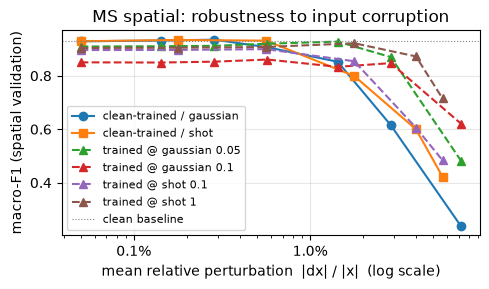

In [11]:
if not phase1:
    print("Run 4.1 first.")
else:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    clean_f1 = next(r["macro_f1"] for r in phase1 if r["noise"] == "none")

    print(f"{'model':<20}{'noise':<14}{'pert':>8}{'macro_f1':>10}{'acc':>9}{'rel':>7}")
    for row in phase1:
        label = "clean" if row["noise"] == "none" else f"{row['noise']} {row['level']:g}"
        print(f"{'clean-trained':<20}{label:<14}{row['perturbation']:>7.1%}"
              f"{row['macro_f1']:>10.4f}{row['accuracy']:>9.4f}"
              f"{row['macro_f1'] / clean_f1:>7.3f}")
    for entry in phase2:
        name = f"trained {entry['train_noise'][:5]} {entry['train_level']:g}"
        for row in entry["curve"]:
            label = "clean" if row["noise"] == "none" else f"{row['noise']} {row['level']:g}"
            print(f"{name:<20}{label:<14}{row['perturbation']:>7.1%}"
                  f"{row['macro_f1']:>10.4f}{row['accuracy']:>9.4f}"
                  f"{row['macro_f1'] / clean_f1:>7.3f}")

    CLEAN_PLACEHOLDER = 5e-4

    def curve(rows, kind):
        points = sorted(
            (r for r in rows if r["noise"] in ("none", kind)),
            key=lambda r: r["perturbation"],
        )
        xs = [r["perturbation"] if r["perturbation"] > 0 else CLEAN_PLACEHOLDER for r in points]
        ys = [r["macro_f1"] for r in points]
        return xs, ys

    figure, axes = plt.subplots(figsize=(5, 3))
    for kind, marker in (("gaussian", "-o"), ("shot", "-s")):
        x, y = curve(phase1, kind)
        axes.plot(x, y, marker, label=f"clean-trained / {kind}")
    for entry in phase2:
        x, y = curve(entry["curve"], entry["train_noise"])
        axes.plot(x, y, "--^", label=f"trained @ {entry['train_noise']} {entry['train_level']:g}")

    axes.axhline(clean_f1, color="grey", lw=0.8, ls=":", label="clean baseline")
    axes.set_xscale("log")
    axes.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda v, _: "clean" if v <= CLEAN_PLACEHOLDER else f"{v:.1%}"
    ))
    axes.set_xlabel("mean relative perturbation  |dx| / |x|  (log scale)")
    axes.set_ylabel("macro-F1 (spatial validation)")
    axes.set_title("MS spatial: robustness to input corruption")
    axes.legend(fontsize=8)
    axes.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4.3 Test-set noise evaluation

Re-run the phase 1 and phase 2 noise sweeps on the held-out **test** split.
Only run after both phases above are complete.

In [13]:
RUN_TEST_SWEEP = False

phase1_test_path = resolve_project_path("outputs/noise/ms_spatial/phase1_test.json")
phase2_test_path = resolve_project_path("outputs/noise/ms_spatial/phase2_test.json")

if RUN_TEST_SWEEP:
    print("=== Phase 1: clean-trained model on TEST ===")
    phase1_test = sweep_noise(BASELINE_RUN, NOISE_SETTINGS, split="test")
    phase1_test_path.parent.mkdir(parents=True, exist_ok=True)
    phase1_test_path.write_text(json.dumps(phase1_test, indent=2))

    print("\n=== Phase 2: noise-trained models on TEST ===")
    phase2_test = []
    for kind, level in TRAIN_NOISE_LEVELS:
        noisy_config = replace(
            final_config,
            num_workers=4,
            pin_memory=False,
            output_dir=f"./outputs/noise/train/{kind}{level:g}",
        )
        print(f"\n--- {kind} {level:g} trained model ---")
        phase2_test.append({
            "train_noise": kind,
            "train_level": level,
            "curve": sweep_noise(noisy_config.run_dir(), NOISE_SETTINGS, split="test"),
        })
    phase2_test_path.parent.mkdir(parents=True, exist_ok=True)
    phase2_test_path.write_text(json.dumps(phase2_test, indent=2))
elif phase1_test_path.exists() and phase2_test_path.exists():
    phase1_test = json.loads(phase1_test_path.read_text())
    phase2_test = json.loads(phase2_test_path.read_text())
else:
    phase1_test = phase2_test = []
    print("Set RUN_TEST_SWEEP = True after phases 1 & 2 are complete.")

model               noise             pert  macro_f1      acc    rel
clean-trained       clean            0.0%    0.8975   0.9287  1.000
clean-trained       gaussian 0.005   0.1%    0.8987   0.9285  1.001
clean-trained       gaussian 0.01    0.3%    0.8926   0.9239  0.995
clean-trained       gaussian 0.02    0.6%    0.8699   0.9057  0.969
clean-trained       gaussian 0.05    1.4%    0.7537   0.8281  0.840
clean-trained       gaussian 0.1     2.9%    0.5344   0.6035  0.595
clean-trained       gaussian 0.25    7.2%    0.2128   0.2278  0.237
clean-trained       shot 0.01        0.2%    0.8965   0.9272  0.999
clean-trained       shot 0.1         0.6%    0.8729   0.9091  0.973
clean-trained       shot 1           1.8%    0.7247   0.8093  0.807
clean-trained       shot 5           4.0%    0.5485   0.6143  0.611
clean-trained       shot 10          5.6%    0.3911   0.4178  0.436
trained gauss 0.05  clean            0.0%    0.8773   0.9106  0.977
trained gauss 0.05  gaussian 0.005   0.1%    0.

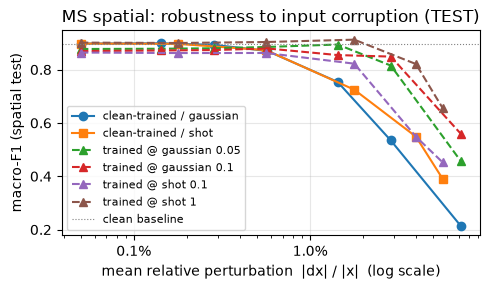

In [14]:
if not phase1_test:
    print("Run 4.3 first.")
else:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    clean_f1 = next(r["macro_f1"] for r in phase1_test if r["noise"] == "none")

    print(f"{'model':<20}{'noise':<14}{'pert':>8}{'macro_f1':>10}{'acc':>9}{'rel':>7}")
    for row in phase1_test:
        label = "clean" if row["noise"] == "none" else f"{row['noise']} {row['level']:g}"
        print(f"{'clean-trained':<20}{label:<14}{row['perturbation']:>7.1%}"
              f"{row['macro_f1']:>10.4f}{row['accuracy']:>9.4f}"
              f"{row['macro_f1'] / clean_f1:>7.3f}")
    for entry in phase2_test:
        name = f"trained {entry['train_noise'][:5]} {entry['train_level']:g}"
        for row in entry["curve"]:
            label = "clean" if row["noise"] == "none" else f"{row['noise']} {row['level']:g}"
            print(f"{name:<20}{label:<14}{row['perturbation']:>7.1%}"
                  f"{row['macro_f1']:>10.4f}{row['accuracy']:>9.4f}"
                  f"{row['macro_f1'] / clean_f1:>7.3f}")

    CLEAN_PLACEHOLDER = 5e-4

    def curve(rows, kind):
        points = sorted(
            (r for r in rows if r["noise"] in ("none", kind)),
            key=lambda r: r["perturbation"],
        )
        xs = [r["perturbation"] if r["perturbation"] > 0 else CLEAN_PLACEHOLDER for r in points]
        ys = [r["macro_f1"] for r in points]
        return xs, ys

    figure, axes = plt.subplots(figsize=(5, 3))
    for kind, marker in (("gaussian", "-o"), ("shot", "-s")):
        x, y = curve(phase1_test, kind)
        axes.plot(x, y, marker, label=f"clean-trained / {kind}")
    for entry in phase2_test:
        x, y = curve(entry["curve"], entry["train_noise"])
        axes.plot(x, y, "--^", label=f"trained @ {entry['train_noise']} {entry['train_level']:g}")

    axes.axhline(clean_f1, color="grey", lw=0.8, ls=":", label="clean baseline")
    axes.set_xscale("log")
    axes.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda v, _: "clean" if v <= CLEAN_PLACEHOLDER else f"{v:.1%}"
    ))
    axes.set_xlabel("mean relative perturbation  |dx| / |x|  (log scale)")
    axes.set_ylabel("macro-F1 (spatial test)")
    axes.set_title("MS spatial: robustness to input corruption (TEST)")
    axes.legend(fontsize=8)
    axes.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()